In [2]:
import pandas as pd
import os
os.getcwd()

'/home/topcuoglu/openrecombinhunt/src/analyse'

In [3]:
virus = "yellow-fever"
metadata_path = f"../../data/raw/{virus}/raw_metadata.tsv" 
df = pd.read_csv(metadata_path, sep="\t")
df.head()

,Accession,BioProjects,BioSample accession,Completeness,Gene count,Geographic Location,Geographic Region,Geographic State,Host Common Name,Host Infraspecific Names Breed,...,Virus Common Name,Virus Infraspecific Names Breed,Virus Infraspecific Names Cultivar,Virus Infraspecific Names Ecotype,Virus Infraspecific Names Isolate,Virus Infraspecific Names Sex,Virus Infraspecific Names Strain,Virus Name,Virus Pangolin Classification,Virus Taxonomic ID
0,A32222.1,NaN,NaN,PARTIAL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yellow fever virus,NaN,11089
1,A32223.1,NaN,NaN,PARTIAL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yellow fever virus,NaN,11089
2,A32224.1,NaN,NaN,PARTIAL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yellow fever virus,NaN,11089
3,A32225.1,NaN,NaN,PARTIAL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yellow fever virus,NaN,11089
4,AF013417.1,NaN,NaN,PARTIAL,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yellow fever virus,NaN,11089


In [15]:
df.info

<bound method DataFrame.info of        Accession BioProjects BioSample accession Completeness  Gene count  \
0       A32222.1         NaN                 NaN      PARTIAL         NaN   
1       A32223.1         NaN                 NaN      PARTIAL         NaN   
2       A32224.1         NaN                 NaN      PARTIAL         NaN   
3       A32225.1         NaN                 NaN      PARTIAL         NaN   
4     AF013417.1         NaN                 NaN      PARTIAL         1.0   
...          ...         ...                 ...          ...         ...   
2261    X03700.1         NaN                 NaN     COMPLETE         1.0   
2262    X15062.1         NaN                 NaN      PARTIAL         1.0   
2263    X53834.1         NaN                 NaN      PARTIAL         NaN   
2264    X53835.1         NaN                 NaN      PARTIAL         NaN   
2265    X53836.1         NaN                 NaN      PARTIAL         NaN   

     Geographic Location Geographic Region 

In [4]:
df.columns

Index(['Accession', 'BioProjects', 'BioSample accession', 'Completeness',
       'Gene count', 'Geographic Location', 'Geographic Region',
       'Geographic State', 'Host Common Name',
       'Host Infraspecific Names Breed', 'Host Infraspecific Names Cultivar',
       'Host Infraspecific Names Ecotype', 'Host Infraspecific Names Isolate',
       'Host Infraspecific Names Sex', 'Host Infraspecific Names Strain',
       'Host Name', 'Host Pangolin Classification', 'Host Taxonomic ID',
       'Is Annotated', 'Is Complete', 'Is Lab Host', 'Is Vaccine Strain',
       'Isolate Collection date', 'Isolate Lineage', 'Isolate Lineage source',
       'Lab Host', 'Length', 'Mature peptide count', 'Molecule type',
       'Nucleotide completeness', 'Protein count', 'Purpose of Sampling',
       'Release date', 'Segment', 'Source database', 'SRA Accessions',
       'Submitter Affiliation', 'Submitter Country', 'Submitter Names',
       'Update date', 'Virus Common Name', 'Virus Infraspecific Names 

In [5]:
# display Completeness column
df['Completeness']

0        PARTIAL
1        PARTIAL
2        PARTIAL
3        PARTIAL
4        PARTIAL
          ...   
2261    COMPLETE
2262     PARTIAL
2263     PARTIAL
2264     PARTIAL
2265     PARTIAL
Name: Completeness, Length: 2266, dtype: object

In [6]:
# count NA in 'Completeness' column
na_count = df['Completeness'].isna().sum()

# count PARTIAL values in 'Completeness' column
partial_count = df['Completeness'].value_counts().get('PARTIAL', 0)

# count COMPLETE values in 'Completeness' column
complete_count = df['Completeness'].value_counts().get('COMPLETE', 0)

print(f"NA count: {na_count}")
print(f"PARTIAL count: {partial_count}")
print(f"COMPLETE count: {complete_count}")

NA count: 0
PARTIAL count: 1945
COMPLETE count: 321


In [7]:
# display Is Complete column
df['Is Complete']

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
2261   NaN
2262   NaN
2263   NaN
2264   NaN
2265   NaN
Name: Is Complete, Length: 2266, dtype: float64

In [8]:
# count NA in Is Complete column
na_count_is_complete = df['Is Complete'].isna().sum()

# count True values in Is Complete column
true_count = df['Is Complete'].value_counts().get(True, 0)

# count False values in Is Complete column
false_count = df['Is Complete'].value_counts().get(False, 0)

print(f"NA count in 'Is Complete': {na_count_is_complete}")
print(f"True count in 'Is Complete': {true_count}")
print(f"False count in 'Is Complete': {false_count}")

NA count in 'Is Complete': 2266
True count in 'Is Complete': 0
False count in 'Is Complete': 0


In [9]:
# display Length column
df['Length']

0          35
1          12
2          27
3          24
4        1035
        ...  
2261    10862
2262    10862
2263      270
2264      270
2265      270
Name: Length, Length: 2266, dtype: int64

In [11]:
# count NA in Length column
na_count_length = df['Length'].isna().sum()
print(f"NA count in 'Length': {na_count_length}")

NA count in 'Length': 0


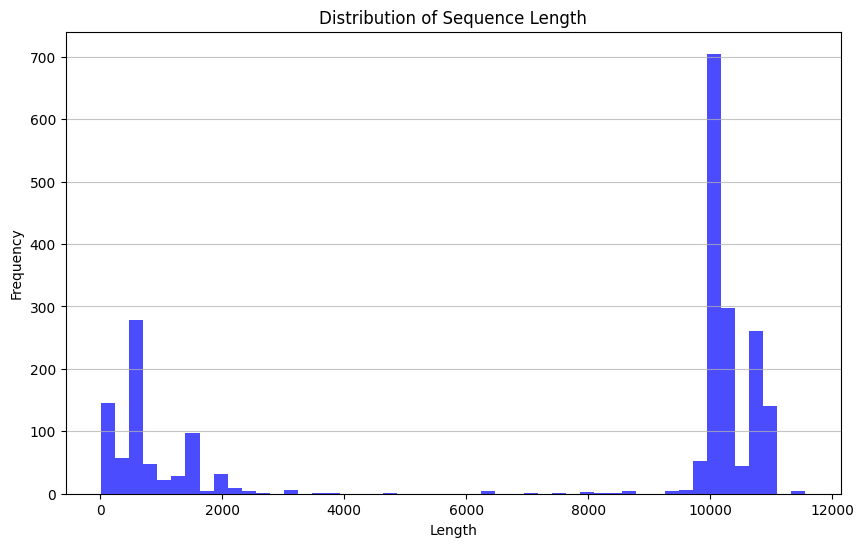

In [13]:
# plot the distribution of Length
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(df['Length'].dropna(), bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Sequence Length')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


In [14]:
# count length less than 9000
length_less_than_9000 = df[df['Length'] < 9000].shape[0]
print(f"Number of sequences with length less than 9000: {length_less_than_9000}")

# count length greater than 9000
length_greater_than_9000 = df[df['Length'] > 9000].shape[0]
print(f"Number of sequences with length greater than 9000: {length_greater_than_9000}")

Number of sequences with length less than 9000: 752
Number of sequences with length greater than 9000: 1514


In [22]:
# display Isolate Collection date column
df['Isolate Collection date'].dropna()

300           1986
301           1990
302           1961
303           1986
304           1990
           ...    
2197    2025-03-10
2198    2024-12-26
2199    2025-01-17
2200    2025-02-18
2201    2023-02-22
Name: Isolate Collection date, Length: 1658, dtype: object

In [17]:
# count NA in Isolate Collection date column
na_count_collection_date = df['Isolate Collection date'].isna().sum()

# count Collection Date in format YYYY-MM-DD
valid_date_count = df['Isolate Collection date'].str.match(r'^\d{4}-\d{2}-\d{2}$').sum()

# count Collection Date in format YYYY-MM
valid_date_count_mm = df['Isolate Collection date'].str.match(r'^\d{4}-\d{2}$').sum()

# count Collection Date in format YYYY
valid_date_count_yyyy = df['Isolate Collection date'].str.match(r'^\d{4}$').sum()

print(f"NA count in 'Collection Date': {na_count_collection_date}")
print(f"Valid date count (YYYY-MM-DD): {valid_date_count}")
print(f"Valid date count (YYYY-MM): {valid_date_count_mm}")
print(f"Valid date count (YYYY): {valid_date_count_yyyy}")

NA count in 'Collection Date': 608
Valid date count (YYYY-MM-DD): 1287
Valid date count (YYYY-MM): 68
Valid date count (YYYY): 303


In [18]:
# discard sequences with 
# NA in 'Isolate Collection date'
# Length < 9000
# Accession is NA
df_filtered = df.dropna(subset=['Isolate Collection date', 'Length', 'Accession'])
df_filtered = df_filtered[df_filtered['Length'] >= 9000]

# report the number of sequences before and after filtering
num_sequences_before = df.shape[0]
num_sequences_after = df_filtered.shape[0]
print(f"Number of sequences before filtering: {num_sequences_before}")
print(f"Number of sequences after filtering: {num_sequences_after}")

Number of sequences before filtering: 2266
Number of sequences after filtering: 1409


In [19]:
# display Release date column
df_filtered['Release date']

344     2005-08-02T00:00:00Z
386     2009-08-25T00:00:00Z
387     2009-08-25T00:00:00Z
438     2010-07-26T00:00:00Z
485     2012-12-06T00:00:00Z
                ...         
2197    2025-06-14T00:00:00Z
2198    2025-06-14T00:00:00Z
2199    2025-06-14T00:00:00Z
2200    2025-06-14T00:00:00Z
2201    2025-06-14T00:00:00Z
Name: Release date, Length: 1409, dtype: object

In [20]:
# count NA in Release date column
na_count_release_date = df_filtered['Release date'].isna().sum()

# count Release date in format YYYY-MM-DD
valid_release_date_count = df_filtered['Release date'].str.match(r'^\d{4}-\d{2}-\d{2}$').sum()

# count Release date in format YYYY-MM
valid_release_date_count_mm = df_filtered['Release date'].str.match(r'^\d{4}-\d{2}$').sum()

# count Release date in format YYYY
valid_release_date_count_yyyy = df_filtered['Release date'].str.match(r'^\d{4}$').sum()

print(f"NA count in 'Release date': {na_count_release_date}")
print(f"Valid release date count (YYYY-MM-DD): {valid_release_date_count}")
print(f"Valid release date count (YYYY-MM): {valid_release_date_count_mm}")
print(f"Valid release date count (YYYY): {valid_release_date_count_yyyy}")

NA count in 'Release date': 0
Valid release date count (YYYY-MM-DD): 0
Valid release date count (YYYY-MM): 0
Valid release date count (YYYY): 0
